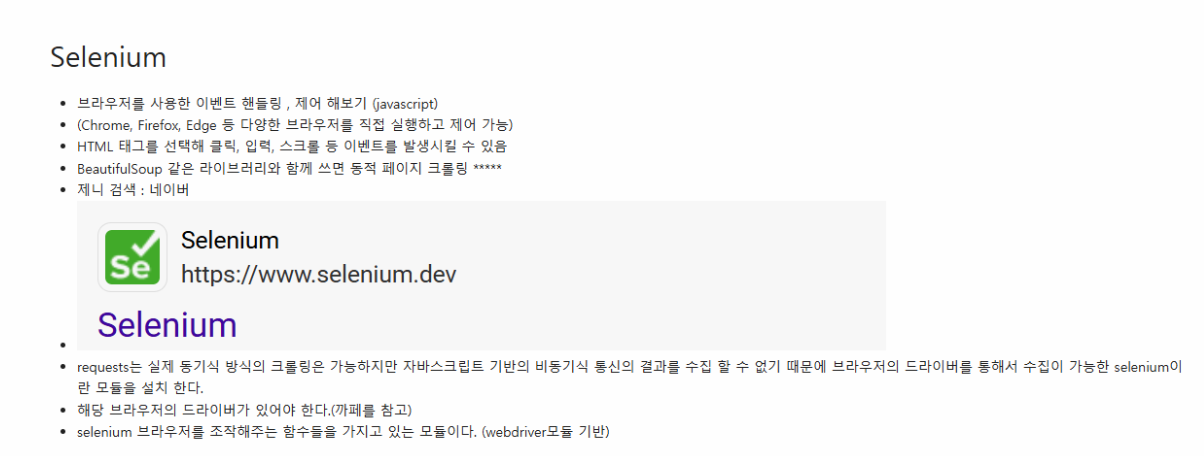

In [1]:
#!pip install selenium

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 'anaconda_projects',
 'chromedriver.exe',
 'SeleniumWin0812.ipynb',
 'Untitled.ipynb']

In [3]:
import selenium
selenium.__version__

'4.47.0'

In [4]:
#!pip install webdriver-manager

In [5]:
#webdriver 모듈에서 Chrome 드라이버 객체 
from selenium import webdriver
#Service : 드라이버 chromedriver.exe 로딩 
from selenium.webdriver.chrome.service import Service
#find_element(By.XX) => find_element_by_id()
from selenium.webdriver.common.by import By
#브라우저 버전관까지 해주는 매니저 
from webdriver_manager.chrome import ChromeDriverManager

In [6]:
#webdriver_manager를 사용해서 해당 버전을 자동으로 로딩 및 초기화
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.get("http://www.naver.com")

In [7]:
element = driver.find_element(By.ID,'newsstand')
print(element)
print(f"element.tag_name : {element.tag_name}")
print('*'*30)
print(f"element.text : {element.text}")

<selenium.webdriver.remote.webelement.WebElement (session="60ec9ef71d5ac3e71f296afe32dcdbbc", element="f.AD37B1EFC0364ABDB4F173FC78A1F95B.d.1C5E3D06E441BAF083BC264CAFA46C95.e.22")>
element.tag_name : div
******************************
element.text : 뉴스스탠드언론사편집
엔터
스포츠LIVE
게임
경제
쇼핑투데이
전체언론사
연합뉴스
北, 한미훈련 앞두고 6일만에 또 탄도미사일…700km 이상 비행
뉴스스탠드뉴스홈
리스트형
썸네일형
이전 페이지
언론사 더보기1
페이지
전체
/4
다음 페이지


In [8]:
# selenium에서 받아온 데이터를 BeautifulSoup으로 정제
from bs4 import BeautifulSoup
# driver.page_source
## selenium에서 받아온 데이터를 PageSource가져온다.
req = driver.page_source
print(req[:100])

<html lang="ko" class="fzoom" data-theme="greenLight"><head><script async="" src="https://ntm.pstati


In [9]:
#연결된 브라우저를 종료 한다.
driver.close()

## GDP 데이터 수집해보기
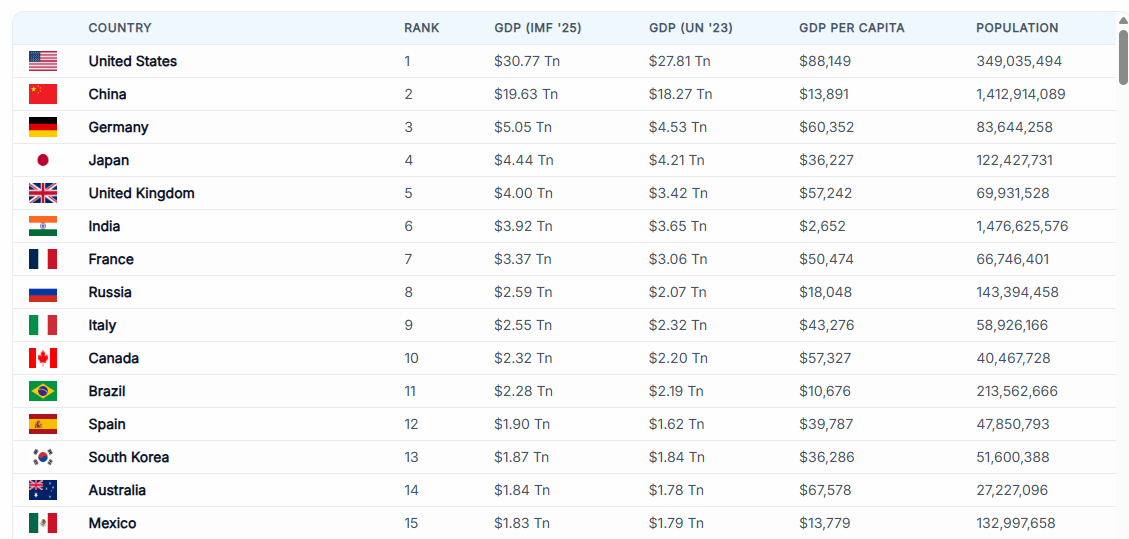

In [10]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import os
import time

In [11]:
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
url = 'https://worldpopulationreview.com/countries/by-gdp'
driver.get(url)
#sleep(3)  지연시간 
time.sleep(3)
req = driver.page_source
soup = BeautifulSoup(req,'html.parser')

In [12]:
res = soup.find('table',class_='wpr-table')
res.text[:100]

"CountryRankGDP (IMF '25)GDP (UN '23)GDP Per CapitaPopulationUnited States1$30.77 Tn$27.81 Tn$88,1493"

In [13]:
# select_one 출력 해보기 
table = soup.select_one("table.wpr-table")
table.text[:100]

"CountryRankGDP (IMF '25)GDP (UN '23)GDP Per CapitaPopulationUnited States1$30.77 Tn$27.81 Tn$88,1493"

In [14]:
theads = table.find('thead')
theads.text

"CountryRankGDP (IMF '25)GDP (UN '23)GDP Per CapitaPopulation"

In [15]:
# th안에 클래스 datable 바로 아래 자식이 div 의 클래스가 fles
# th.datatable-th > div > div.flex
title = theads.select('th.datatable-th > div > div.flex')
#title

In [16]:
listv = [e.text for e in title]
listv

['',
 'Country',
 'Rank',
 "GDP (IMF '25)",
 "GDP (UN '23)",
 'GDP Per Capita',
 'Population']

In [17]:
# 본문 추출 해보기 - table 변수에서 추출 
# 해더는 th구조, 본문은 무슨 구조? 인지 확인 해서 추출해보기
# trs = 
"""
 [1, 'United States', '1', '$30.51 Tn', '$27.72 Tn', '$87,404', '349,035,000'],
 [2, 'China', '2', '$19.23 Tn', '$17.79 Tn', '$13,611', '1,412,910,000'],
 [3, 'Germany', '3', '$4.74 Tn', '$4.53 Tn', '$56,726', '83,644,300'],
 [4, 'India', '4', '$4.19 Tn', '$3.58 Tn', '$2,836', '1,476,630,000'],
 [5, 'Japan', '5', '$4.19 Tn', '$4.20 Tn', '$34,195', '122,428,000'],
 [6, 'United Kingdom', '6', '$3.84 Tn', '$3.38 Tn', '$54,899', '69,931,500'],
 [7, 'France', '7', '$3.21 Tn', '$3.05 Tn', '$48,112', '66,746,400'],
 [8, 'Italy', '8', '$2.42 Tn', '$2.30 Tn', '$41,117', '58,926,200'],
 [9, 'Canada', '9', '$2.23 Tn', '$2.14 Tn', '$54,991', '40,467,700'],
 [10, 'Brazil', '10', '$2.13 Tn', '$2.19 Tn', '$9,955', '213,563,000'],
 [11, 'Russia', '11', '$2.08 Tn', '$2.01 Tn', '$14,480', '143,394,000'],
 [12, 'Spain', '12', '$1.80 Tn', '$1.62 Tn', '$37,607', '47,850,800'],
 [13, 'South Korea', '13', '$1.79 Tn', '$1.84 Tn', '$34,696', '51,600,400'],
 [14, 'Australia', '14', '$1.77 Tn', '$1.78 Tn', '$65,070', '27,227,100']]

"""
trs = table.find_all('tr')
trs[1] , type(trs)

(<tr class="table-row hover:bg-gray-50" data-astro-cid-ehxcqswa=""><td class="border-wpr-table_border border-t px-3 py-1.5 text-sm md:px-4 sticky-col sticky left-0 z-30 bg-white font-bold shadow-[2px_0_5px_-2px_rgba(0,0,0,0.1)] after:hidden after:content-['']" data-astro-cid-ehxcqswa=""><img alt="United States Flag" class="min-w-7 min-h-5 w-7 h-5" height="20" src="/images/country-flags/h24/us.png" width="28"/></td><td class="border-wpr-table_border border-t px-3 py-1.5 text-sm md:px-4 false font-bold" data-astro-cid-ehxcqswa=""><a href="/countries/united-states">United States</a></td><td class="border-wpr-table_border border-t px-3 py-1.5 text-sm md:px-4 false" data-astro-cid-ehxcqswa="">1</td><td class="border-wpr-table_border border-t px-3 py-1.5 text-sm md:px-4 false" data-astro-cid-ehxcqswa="">$30.77 Tn</td><td class="border-wpr-table_border border-t px-3 py-1.5 text-sm md:px-4 false" data-astro-cid-ehxcqswa="">$27.81 Tn</td><td class="border-wpr-table_border border-t px-3 py-1.5 t

In [18]:
# 2중리스트 => 판다스로 쉽게 변환이 가능!!
row = []
for idx, tr in enumerate(trs):
    if idx == 0:
        row.append(listv)
    else:
        resv = [td.get_text(strip=True) for td in tr.find_all('td')]
        resv.insert(0,idx)
        row.append(resv)
    #print(idx,tr.text)
row

[['',
  'Country',
  'Rank',
  "GDP (IMF '25)",
  "GDP (UN '23)",
  'GDP Per Capita',
  'Population'],
 [1,
  '',
  'United States',
  '1',
  '$30.77 Tn',
  '$27.81 Tn',
  '$88,149',
  '349,035,494'],
 [2, '', 'China', '2', '$19.63 Tn', '$18.27 Tn', '$13,891', '1,412,914,089'],
 [3, '', 'Germany', '3', '$5.05 Tn', '$4.53 Tn', '$60,352', '83,644,258'],
 [4, '', 'Japan', '4', '$4.44 Tn', '$4.21 Tn', '$36,227', '122,427,731'],
 [5,
  '',
  'United Kingdom',
  '5',
  '$4.00 Tn',
  '$3.42 Tn',
  '$57,242',
  '69,931,528'],
 [6, '', 'India', '6', '$3.92 Tn', '$3.65 Tn', '$2,652', '1,476,625,576'],
 [7, '', 'France', '7', '$3.37 Tn', '$3.06 Tn', '$50,474', '66,746,401'],
 [8, '', 'Russia', '8', '$2.59 Tn', '$2.07 Tn', '$18,048', '143,394,458'],
 [9, '', 'Italy', '9', '$2.55 Tn', '$2.32 Tn', '$43,276', '58,926,166'],
 [10, '', 'Canada', '10', '$2.32 Tn', '$2.20 Tn', '$57,327', '40,467,728'],
 [11, '', 'Brazil', '11', '$2.28 Tn', '$2.19 Tn', '$10,676', '213,562,666'],
 [12, '', 'Spain', '12', '

In [ ]:
# 여기까지가 데이터 수집 종료~~~~~~~~~~~~~~

In [19]:
import pandas as pd

In [20]:
pd.__version__

'2.3.3'

In [21]:
row[0]

['',
 'Country',
 'Rank',
 "GDP (IMF '25)",
 "GDP (UN '23)",
 'GDP Per Capita',
 'Population']

In [22]:
#pd.DataFrame(data,columns=row[0])
row[0].insert(0,"Index")
df = pd.DataFrame(row[1:],columns=row[0])
df.head(11)

,Index,,Country,Rank,GDP (IMF '25),GDP (UN '23),GDP Per Capita,Population
0,1,,United States,1,$30.77 Tn,$27.81 Tn,"$88,149","349,035,494"
1,2,,China,2,$19.63 Tn,$18.27 Tn,"$13,891","1,412,914,089"
2,3,,Germany,3,$5.05 Tn,$4.53 Tn,"$60,352","83,644,258"
3,4,,Japan,4,$4.44 Tn,$4.21 Tn,"$36,227","122,427,731"
4,5,,United Kingdom,5,$4.00 Tn,$3.42 Tn,"$57,242","69,931,528"
5,6,,India,6,$3.92 Tn,$3.65 Tn,"$2,652","1,476,625,576"
6,7,,France,7,$3.37 Tn,$3.06 Tn,"$50,474","66,746,401"
7,8,,Russia,8,$2.59 Tn,$2.07 Tn,"$18,048","143,394,458"
8,9,,Italy,9,$2.55 Tn,$2.32 Tn,"$43,276","58,926,166"
9,10,,Canada,10,$2.32 Tn,$2.20 Tn,"$57,327","40,467,728"


In [23]:
#컬럼 정보 추출
df.columns

Index(['Index', '', 'Country', 'Rank', 'GDP (IMF '25)', 'GDP (UN '23)',
       'GDP Per Capita', 'Population'],
      dtype='object')

In [25]:
df["GDP (UN '23)"].head(2)

0    $27.81 Tn
1    $18.27 Tn
Name: GDP (UN '23), dtype: object

In [32]:
# $27.72 Tn , $17.79 Tn 데이터를 순수한 수치형으로 변경 하기위한 전처리 
# ^ ->시작 , $ ->끝 [^] ->그룹안에 포함된 형식은 제외한다.
df["GDP (UN '23)"].replace("[^0-9]","",regex=True)
df["GDP (UN '23)"].replace(".[a-zA-Z]{2}$","",regex=True)
type(df["GDP (UN '23)"].replace(".[a-zA-Z]{2}$","",regex=True)[0])
df["GDP (UN '23)"].replace(".[a-zA-Z]{2}$","",regex=True).str.replace("$","",regex=False) #$는 문자열 자체를 제거 정규표현식 X

0       27.81
1       18.27
2        4.53
3        4.21
4        3.42
        ...  
206      1.56
207      9.77
208    429.45
209     26.19
210      1.65
Name: GDP (UN '23), Length: 211, dtype: object

In [33]:
len(df.columns)

8

In [35]:
#새로운 컬럼을 추가해보기 -> 딕셔너리 처럼 가능 
df['newCol'] = df["GDP (UN '23)"].replace(".[a-zA-Z]{2}$","",regex=True).str.replace("$","",regex=False) 
df.head(2)

,Index,,Country,Rank,GDP (IMF '25),GDP (UN '23),GDP Per Capita,Population,newCol
0,1,,United States,1,$30.77 Tn,$27.81 Tn,"$88,149","349,035,494",27.81
1,2,,China,2,$19.63 Tn,$18.27 Tn,"$13,891","1,412,914,089",18.27


In [36]:
#DataFrame을 불러왔다 
#데이터의 정보를 보는 습괸
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Index           211 non-null    int64 
 1                   211 non-null    object
 2   Country         211 non-null    object
 3   Rank            211 non-null    object
 4   GDP (IMF '25)   211 non-null    object
 5   GDP (UN '23)    211 non-null    object
 6   GDP Per Capita  211 non-null    object
 7   Population      211 non-null    object
 8   newCol          211 non-null    object
dtypes: int64(1), object(8)
memory usage: 15.0+ KB


In [37]:
df['newCol']

0       27.81
1       18.27
2        4.53
3        4.21
4        3.42
        ...  
206      1.56
207      9.77
208    429.45
209     26.19
210      1.65
Name: newCol, Length: 211, dtype: object

In [39]:
# pd.to_numeric(df[col],erros='coerce') *****
# 혹시나 숫자형 문자가 아닌 것도 강제로 무시하고 erros='coerce'
df['newCol'] = pd.to_numeric(df['newCol'],errors='coerce')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           211 non-null    int64  
 1                   211 non-null    object 
 2   Country         211 non-null    object 
 3   Rank            211 non-null    object 
 4   GDP (IMF '25)   211 non-null    object 
 5   GDP (UN '23)    211 non-null    object 
 6   GDP Per Capita  211 non-null    object 
 7   Population      211 non-null    object 
 8   newCol          211 non-null    float64
dtypes: float64(1), int64(1), object(7)
memory usage: 15.0+ KB


In [42]:
#!pip install matplotlib

In [41]:
import matplotlib.pyplot as plt

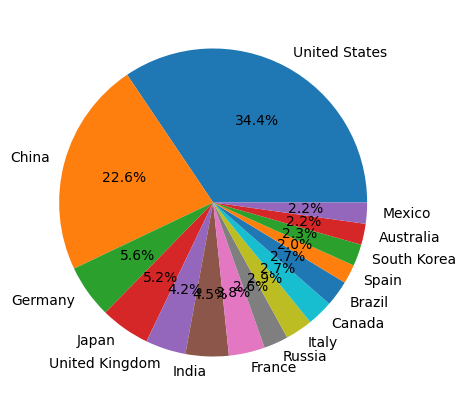

In [44]:
plt.figure(figsize=(5,5)) # 도화지 크기
my_labels = df['Country'].head(15)
#my_labels
#autopct='%1.1f%%' :파이 그래프 안에 수치 타임 % [10.1%] %
plt.pie(df['newCol'].head(15),labels=my_labels,autopct='%1.1f%%')
plt.show()

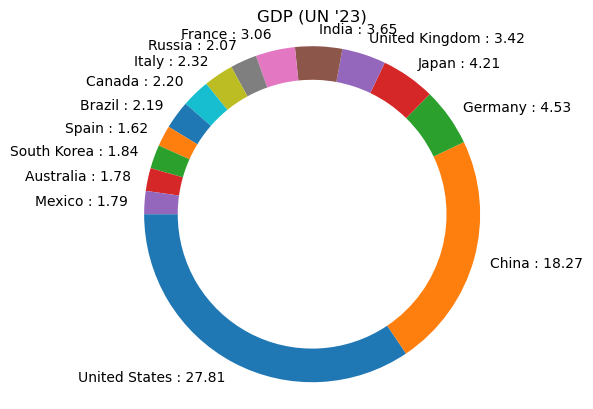

In [58]:
sizes = df['newCol'].head(15)
countries = df['Country'].head(15)
#zip 함수 : 하나 이상의 리스트를 마치 김밥썰 듯이 같은 요소를 잘라내서 제네이터로 반환 => tuple
#list(zip(countries,sizes))
labels = [f'{cn} : {size:.2f}' for cn,size in zip(countries,sizes)] 
#labels
#autopct=None -> 커스터 마이징을 하기 위해서 None 
#startangle=90 -> 90도에서 시작하겠다.
#plt.pie(df["newCol"].head(15),labels=my_labels,autopct='%1.1f%%')
#pctdistance=0.85 : 0.85만큼 약간 안쪽으로 이동하겠다.
plt.pie(sizes, labels=labels, autopct=None, startangle=180, 
        pctdistance=0.85,wedgeprops={'width':0.2})
plt.title('GDP (UN \'23)')
plt.axis('equal')
plt.show()